# Module – Business Insights

## 1. Load the Dataset

In this notebook, we will use the EDA results to identify important patterns, relationships, trends, anomalies, and possible business insights.

First, we load the dataset and check the available data before starting the analysis.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("data/hotel_bookings.csv")

df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


## 2. Booking Cancellation by Hotel Type

In this step, we compare the cancellation rate between different hotel types.

The purpose is to find whether one hotel type has a higher cancellation rate than the other.

In [3]:
cancellation_by_hotel = df.groupby("hotel")["is_canceled"].mean() * 100

cancellation_by_hotel.round(2)

hotel
City Hotel      41.73
Resort Hotel    27.76
Name: is_canceled, dtype: float64

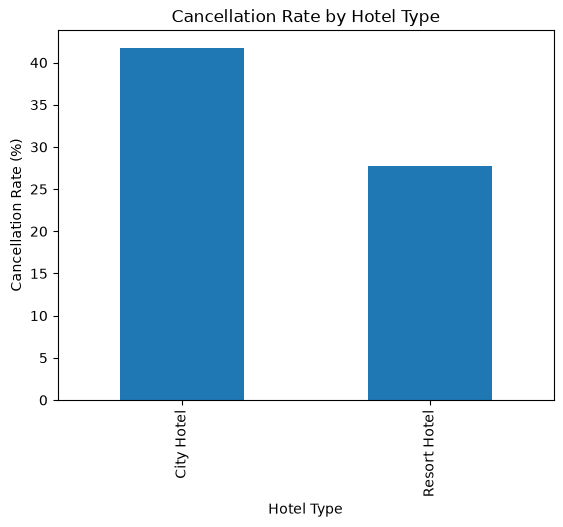

In [4]:
cancellation_by_hotel.plot(kind="bar")

plt.title("Cancellation Rate by Hotel Type")
plt.xlabel("Hotel Type")
plt.ylabel("Cancellation Rate (%)")
plt.show()

## 3. Cancellation by Customer Type

In this step, we compare cancellation rates for different customer types.

The purpose is to understand whether some customer groups cancel their bookings more often.

In [5]:
cancellation_by_customer = df.groupby("customer_type")["is_canceled"].mean() * 100

cancellation_by_customer.round(2)

customer_type
Contract           30.96
Group              10.23
Transient          40.75
Transient-Party    25.43
Name: is_canceled, dtype: float64

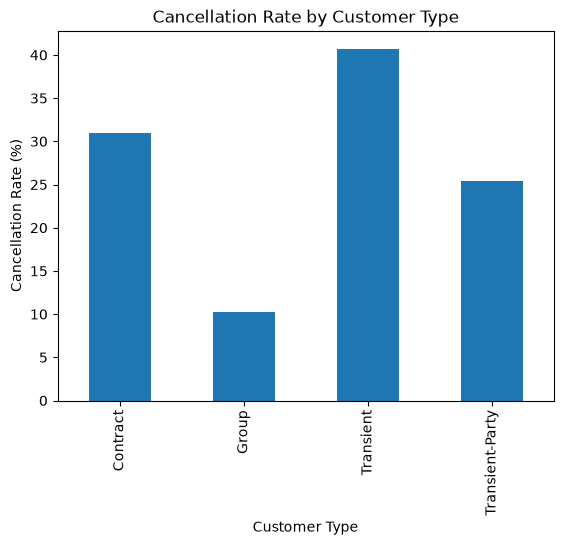

In [6]:
cancellation_by_customer.plot(kind="bar")

plt.title("Cancellation Rate by Customer Type")
plt.xlabel("Customer Type")
plt.ylabel("Cancellation Rate (%)")
plt.show()

## 4. Cancellation by Deposit Type

In this step, we compare the cancellation rate for different deposit types.

The purpose is to understand whether the deposit type has any relationship with booking cancellations.

In [8]:
cancellation_by_deposit = df.groupby("deposit_type")["is_canceled"].mean() * 100

cancellation_by_deposit.round(2)

deposit_type
No Deposit    28.38
Non Refund    99.36
Refundable    22.22
Name: is_canceled, dtype: float64

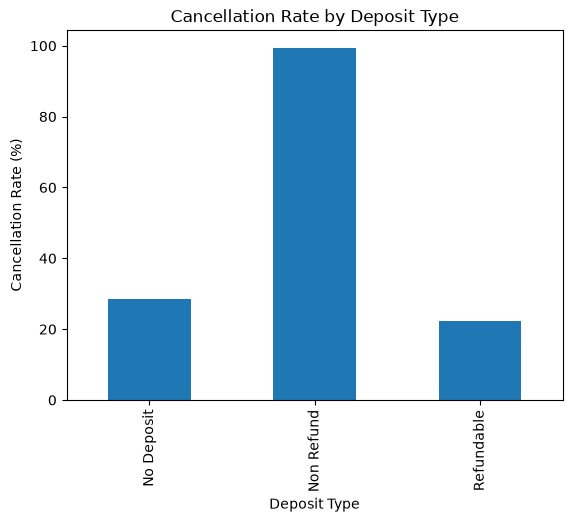

In [9]:
cancellation_by_deposit.plot(kind="bar")

plt.title("Cancellation Rate by Deposit Type")
plt.xlabel("Deposit Type")
plt.ylabel("Cancellation Rate (%)")
plt.show()

## 5. Cancellation by Market Segment

In this step, we compare the cancellation rate across different market segments.

The purpose is to understand whether some market segments have a higher chance of cancellation.

In [10]:
cancellation_by_market = df.groupby("market_segment")["is_canceled"].mean() * 100

cancellation_by_market.round(2)

market_segment
Aviation          21.94
Complementary     13.06
Corporate         18.73
Direct            15.34
Groups            61.06
Offline TA/TO     34.32
Online TA         36.72
Undefined        100.00
Name: is_canceled, dtype: float64

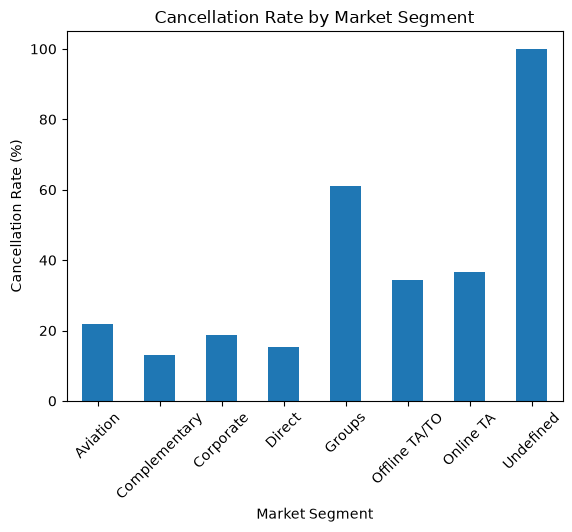

In [11]:
cancellation_by_market.plot(kind="bar")

plt.title("Cancellation Rate by Market Segment")
plt.xlabel("Market Segment")
plt.ylabel("Cancellation Rate (%)")
plt.xticks(rotation=45)
plt.show()

## 6. Cancellation by Customer Type and Hotel Type

In this step, we compare cancellation rates using both customer type and hotel type.

The purpose is to identify whether a specific customer group and hotel combination has a higher cancellation rate.

In [12]:
cancellation_segment = df.groupby(
    ["customer_type", "hotel"]
)["is_canceled"].mean() * 100

cancellation_segment.round(2)

customer_type    hotel       
Contract         City Hotel      48.04
                 Resort Hotel     8.84
Group            City Hotel       9.90
                 Resort Hotel    10.56
Transient        City Hotel      45.62
                 Resort Hotel    31.17
Transient-Party  City Hotel      28.10
                 Resort Hotel    19.50
Name: is_canceled, dtype: float64

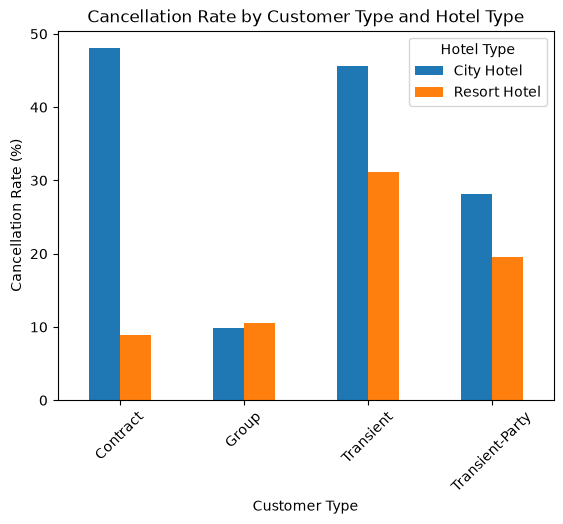

In [13]:
cancellation_segment.unstack().plot(kind="bar")

plt.title("Cancellation Rate by Customer Type and Hotel Type")
plt.xlabel("Customer Type")
plt.ylabel("Cancellation Rate (%)")
plt.xticks(rotation=45)
plt.legend(title="Hotel Type")
plt.show()

## 7. Average Daily Rate by Hotel Type

In this step, we compare the average daily rate between different hotel types.

The purpose is to understand the difference in pricing between the hotel types.

In [14]:
adr_by_hotel = df.groupby("hotel")["adr"].mean()

adr_by_hotel.round(2)

hotel
City Hotel      105.30
Resort Hotel     94.95
Name: adr, dtype: float64

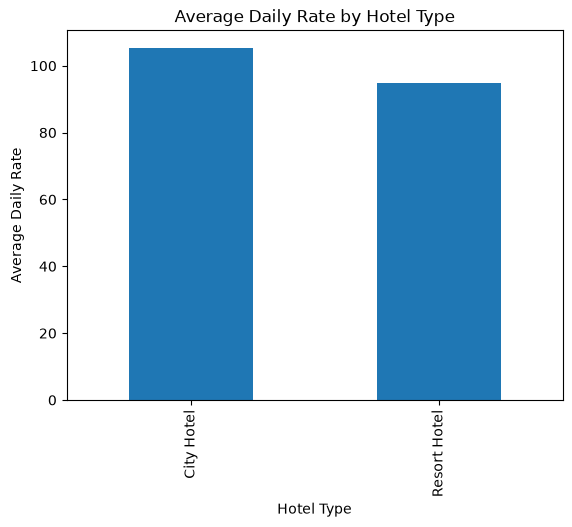

In [15]:
adr_by_hotel.plot(kind="bar")

plt.title("Average Daily Rate by Hotel Type")
plt.xlabel("Hotel Type")
plt.ylabel("Average Daily Rate")
plt.show()

## 8. Cancellation by Lead Time

In this step, we compare the booking lead time with cancellation.

The purpose is to understand whether bookings made far in advance have a different cancellation rate.

In [16]:
lead_time_cancel = df.groupby("is_canceled")["lead_time"].mean()

lead_time_cancel.round(2)

is_canceled
0     79.98
1    144.85
Name: lead_time, dtype: float64

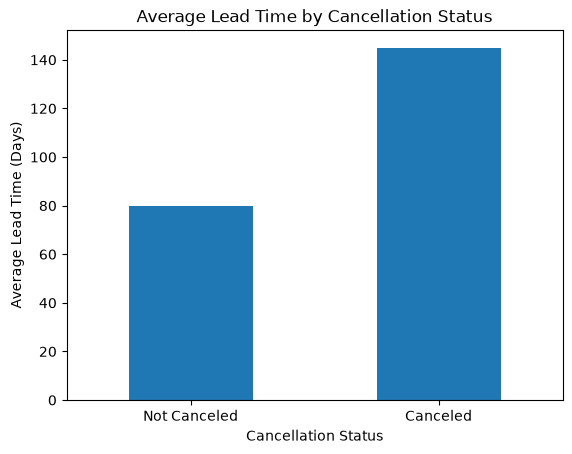

In [17]:
lead_time_cancel.plot(kind="bar")

plt.title("Average Lead Time by Cancellation Status")
plt.xlabel("Cancellation Status")
plt.ylabel("Average Lead Time (Days)")
plt.xticks([0, 1], ["Not Canceled", "Canceled"], rotation=0)
plt.show()

## 9. Cancellation by Booking Changes

In this step, we compare the number of booking changes with cancellation status.

The purpose is to understand whether customers who make more changes to their booking are more likely to cancel.

In [18]:
booking_changes_cancel = df.groupby("is_canceled")["booking_changes"].mean()

booking_changes_cancel.round(2)

is_canceled
0    0.29
1    0.10
Name: booking_changes, dtype: float64

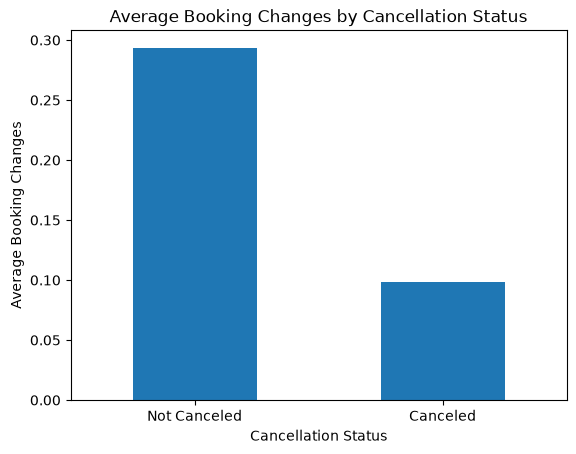

In [19]:
booking_changes_cancel.plot(kind="bar")

plt.title("Average Booking Changes by Cancellation Status")
plt.xlabel("Cancellation Status")
plt.ylabel("Average Booking Changes")
plt.xticks([0, 1], ["Not Canceled", "Canceled"], rotation=0)
plt.show()

## 10. Business Insights

Based on the analysis, we identify important observations from the data and explain what they may mean for the business.

### Insight 1 – Hotel Type and Cancellation

Observation:
The cancellation rate is different between the two hotel types.

Insight:
One hotel type has a higher cancellation rate than the other.

Business Meaning:
The hotel with the higher cancellation rate may need further analysis to understand the reason for cancellations.

### Insight 2 – Customer Type and Cancellation

Observation:
Cancellation rates are different across customer types.

Insight:
Some customer groups are more likely to cancel their bookings.

Business Meaning:
These customer groups can be studied further to understand their booking behavior.

### Insight 3 – Deposit Type and Cancellation

Observation:
Cancellation rates vary across deposit types.

Insight:
Deposit type appears to have a relationship with booking cancellation.

Business Meaning:
The business can study whether changes in deposit policies could help reduce cancellations.

### Insight 4 – Market Segment and Cancellation

Observation:
Different market segments show different cancellation rates.

Insight:
Some market segments have a higher cancellation rate than others.

Business Meaning:
The business can focus on high-cancellation segments and understand the reasons behind the cancellations.

### Insight 5 – Hotel Type and Pricing

Observation:
The average daily rate is different between hotel types.

Insight:
One hotel type has a higher average daily rate.

Business Meaning:
The business can compare pricing and customer demand between the hotel types.